In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
communications_df = pd.read_csv("archive/communications_data.csv")
demographics_df = pd.read_csv("archive/demographics_data.csv")
economy_df = pd.read_csv("archive/economy_data.csv")
energy_df = pd.read_csv("archive/energy_data.csv")
geography_df = pd.read_csv("archive/geography_data.csv")
government_df = pd.read_csv("archive/government_and_civics_data.csv")







In [22]:
communications_df = communications_df.drop(columns=["internet_country_code"])
economy_df = economy_df.drop(columns=["Fiscal_Year"])
geography_df = geography_df.drop(columns=["Geographic_Coordinates","Land_Area","Water_Area","Land_Boundaries","Coastline","Permanent_Crops (%% of Total Agricultural Land)","Permanent_Pasture (%% of Total Agricultural Land)","Irrigated_Land"])
government_df = government_df.drop(columns=["Capital_Coordinates"])


In [23]:
communications_before=communications_df.copy()
demographics_before=demographics_df.copy()
economy_before=economy_df.copy()
energy_before=energy_df.copy()
geography_before=geography_df.copy()
government_before=government_df.copy()



In [24]:
recognized_states = [
 "AFGHANISTAN",
    "ALBANIA", "ALGERIA", "ANDORRA", "ANGOLA", "ANTIGUA AND BARBUDA", "ARGENTINA", "ARMENIA", "AUSTRALIA",
    "AUSTRIA", "AZERBAIJAN", "BAHAMAS, THE","BAHRAIN", "BANGLADESH", "BARBADOS", "BELARUS", "BELGIUM", "BELIZE", "BENIN",
    "BHUTAN", "BOLIVIA","BOSNIA AND HERZEGOVINA","BOTSWANA","BRAZIL","BRUNEI","BULGARIA", "BURKINA FASO",
    "BURUNDI", "CABO VERDE","CAMBODIA","CAMEROON","CANADA","CENTRAL AFRICAN REPUBLIC", "CHAD","CHILE",
    "CHINA", "COLOMBIA", "COMOROS","CONGO, DEMOCRATIC REPUBLIC OF THE","CONGO, REPUBLIC OF THE",
    "COSTA RICA","CROATIA","CUBA","CYPRUS","CZECHIA","DENMARK","DJIBOUTI","DOMINICA","DOMINICAN REPUBLIC",
    "ECUADOR","EGYPT","EL SALVADOR","EQUATORIAL GUINEA","ERITREA","ESTONIA","ESWATINI","ETHIOPIA","FIJI",
    "FINLAND","FRANCE","GABON","GAMBIA, THE","GEORGIA","GERMANY","GHANA","GREECE","GRENADA","GUATEMALA",
    "GUINEA","GUINEA-BISSAU","GUYANA","HAITI","HONDURAS","HUNGARY","ICELAND","INDIA","INDONESIA","IRAN",
    "IRAQ","IRELAND","ISRAEL","ITALY","JAMAICA","JAPAN","JORDAN","KAZAKHSTAN","KENYA","KIRIBATI","KOREA, NORTH",
    "KOREA, SOUTH","KOSOVO","KUWAIT","KYRGYZSTAN","LAOS","LATVIA","LEBANON","LESOTHO","LIBERIA","LIBYA","LIECHTENSTEIN",
    "LITHUANIA","LUXEMBOURG","MADAGASCAR","MALAWI","MALAYSIA","MALDIVES","MALI","MALTA","MARSHALL ISLANDS",
    "MAURITANIA","MAURITIUS","MEXICO","MICRONESIA, FEDERATED STATES OF","MOLDOVA","MONACO","MONGOLIA",
    "MONTENEGRO","MOROCCO","MOZAMBIQUE","MYANMAR","NAMIBIA","NAURU","NEPAL","NETHERLANDS","NEW ZEALAND","NICARAGUA",
    "NIGER","NIGERIA","NORTH MACEDONIA","NORWAY","OMAN","PAKISTAN","PALAU","PANAMA","PAPUA NEW GUINEA",
    "PARAGUAY","PERU","PHILIPPINES","POLAND","PORTUGAL","QATAR","ROMANIA","RUSSIA","RWANDA","SAINT KITTS AND NEVIS",
    "SAINT LUCIA","SAINT VINCENT AND THE GRENADINES","SAMOA","SAN MARINO","SAO TOME AND PRINCIPE",
    "SAUDI ARABIA","SENEGAL","SERBIA","SEYCHELLES","SIERRA LEONE","SINGAPORE","SLOVAKIA","SLOVENIA",
    "SOLOMON ISLANDS","SOMALIA","SOUTH AFRICA","SOUTH SUDAN","SPAIN","SRI LANKA","SUDAN","SURINAME","SWEDEN",
    "SWITZERLAND","SYRIA","TAJIKISTAN","TANZANIA","THAILAND","TIMOR-LESTE","TOGO","TONGA","TRINIDAD AND TOBAGO",
    "TUNISIA","TURKEY (TURKIYE)","TURKMENISTAN","TUVALU","UGANDA","UKRAINE","UNITED ARAB EMIRATES","UNITED KINGDOM",
    "UNITED STATES","URUGUAY","UZBEKISTAN","VANUATU","VENEZUELA","VIETNAM","YEMEN","ZAMBIA","ZIMBABWE","HOLY SEE (VATICAN CITY)",
]
orig_comm = len(communications_df)
orig_econ = len(economy_df)
orig_energy = len(energy_df)
orig_geo = len(geography_df)
orig_gov = len(government_df)

# Apply country filter
communications_df = communications_df[communications_df["Country"].isin(recognized_states)]
economy_df = economy_df[economy_df["Country"].isin(recognized_states)]
energy_df = energy_df[energy_df["Country"].isin(recognized_states)]
geography_df = geography_df[geography_df["Country"].isin(recognized_states)]
government_df = government_df[government_df["Country"].isin(recognized_states)]
demographics_df = demographics_df[demographics_df["Country"].isin(recognized_states)]

# Save filtered sizes
new_comm = len(communications_df)
new_econ = len(economy_df)
new_energy = len(energy_df)
new_geo = len(geography_df)
new_gov = len(government_df)

# Calculate removed
removed_comm = orig_comm - new_comm
removed_econ = orig_econ - new_econ
removed_energy = orig_energy - new_energy
removed_geo = orig_geo - new_geo
removed_gov = orig_gov - new_gov

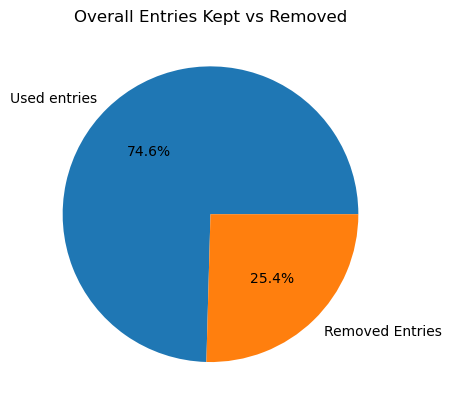

In [25]:


total_used = new_comm + new_econ + new_energy + new_geo + new_gov

# Total rows removed
total_removed = removed_comm + removed_econ + removed_energy + removed_geo + removed_gov

import matplotlib.pyplot as plt

data = [total_used, total_removed]
labels = ["Used entries", "Removed Entries"]

plt.figure()
plt.pie(data, labels=labels, autopct="%1.1f%%")
plt.title("Overall Entries Kept vs Removed")
plt.show()

In [26]:
communications_df=communications_df.drop_duplicates()
economy_df=economy_df.drop_duplicates()
energy_df=energy_df.drop_duplicates()
geography_df=geography_df.drop_duplicates()
government_df=government_df.drop_duplicates()
demographics_df=demographics_df.drop_duplicates()
communications_df.head()

,Country,telephone_fixed_subscriptions_total,mobile_cellular_subscriptions_total,internet_users_total,broadband_fixed_subscriptions_total
0,AFGHANISTAN,150000.0,23000000.0,7020000,26570.0
2,ALBANIA,197690.0,2635466.0,2291000,508937.0
3,ALGERIA,5097095.0,47028685.0,31240000,3790459.0
5,ANDORRA,19075931.0,56805348.0,44180000,16188502.0
6,ANGOLA,119826.0,15327864.0,11550000,230610.0


In [27]:
missing_percentage_communications = communications_df.isnull().mean()
missing_percentage_economy = economy_df.isnull().mean()
missing_percentage_energy = energy_df.isnull().mean()
missing_percentage_geography = geography_df.isnull().mean()
missing_percentage_government = government_df.isnull().mean()
missing_percentage_demographics = demographics_df.isnull().mean()

communications_df = communications_df.drop(columns = missing_percentage_communications[missing_percentage_communications > 0.5].index)
economy_df = economy_df.drop(columns = missing_percentage_economy[missing_percentage_economy > 0.5].index)
energy_df = energy_df.drop(columns = missing_percentage_energy[missing_percentage_energy > 0.5].index)
geography_df = geography_df.drop(columns = missing_percentage_geography[missing_percentage_geography > 0.5].index)
government_df = government_df.drop(columns = missing_percentage_government[missing_percentage_government > 0.5].index)
demographics_df = demographics_df.drop(columns = missing_percentage_demographics[missing_percentage_demographics > 0.5].index)


In [28]:
def fix_comma_names(name: str):
    if pd.isna(name):
        return name
    
    name = name.strip()
    
    if "," not in name:
        return name.title()
    
    first, second = [p.strip() for p in name.split(",", 1)]
    fixed = f"{second} {first}"
    fixed = fixed.title()
    return fixed

communications_df["Country"] = communications_df["Country"].apply(fix_comma_names)
economy_df["Country"] = economy_df["Country"].apply(fix_comma_names)
energy_df["Country"] = energy_df["Country"].apply(fix_comma_names)
geography_df["Country"] = geography_df["Country"].apply(fix_comma_names)
government_df["Country"] = government_df["Country"].apply(fix_comma_names)
demographics_df["Country"] = demographics_df["Country"].apply(fix_comma_names)

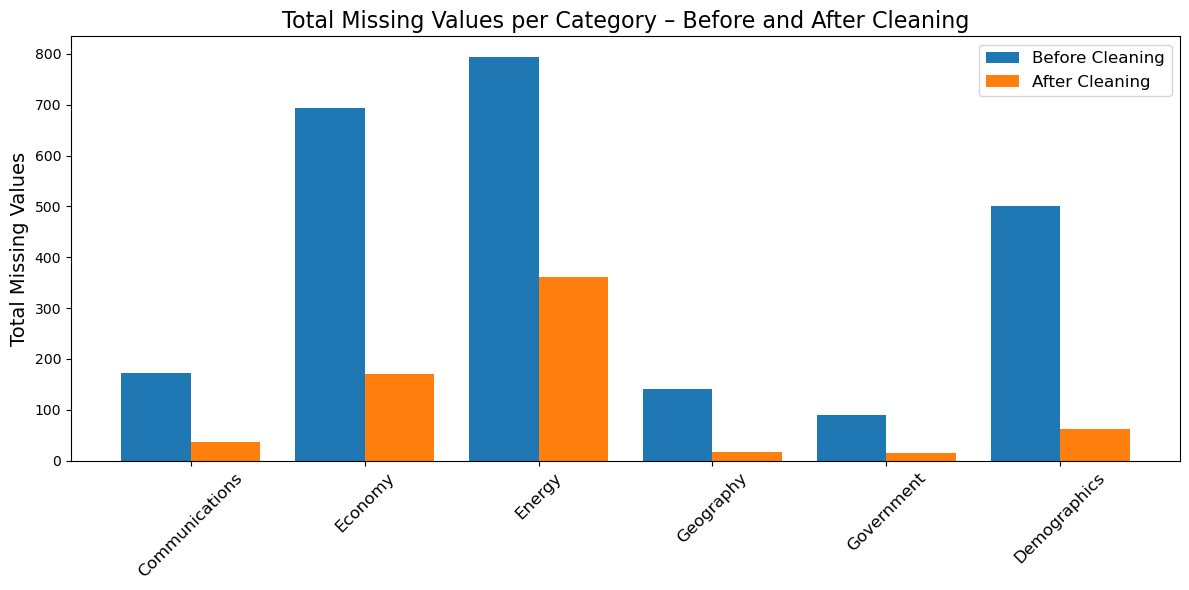

In [29]:
datasets = [
    ("Communications", communications_before, communications_df),
    ("Economy", economy_before, economy_df),
    ("Energy", energy_before, energy_df),
    ("Geography", geography_before, geography_df),
    ("Government", government_before, government_df),
    ("Demographics", demographics_before, demographics_df)
]

dataset_names = []
missing_before_total = []
missing_after_total = []

for name, df_before, df_after in datasets:
    dataset_names.append(name)
    # Total missing values in the whole dataset
    missing_before_total.append(df_before.isna().sum().sum())
    missing_after_total.append(df_after.isna().sum().sum())

x = range(len(dataset_names))
bar_width = 0.4

plt.figure(figsize=(12, 6))
plt.bar([i - bar_width/2 for i in x], missing_before_total, width=bar_width, label="Before Cleaning")
plt.bar([i + bar_width/2 for i in x], missing_after_total, width=bar_width, label="After Cleaning")

plt.xticks(x, dataset_names, rotation=45, fontsize=12)
plt.ylabel("Total Missing Values", fontsize=14)
plt.title("Total Missing Values per Category – Before and After Cleaning", fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
communications_df.to_csv("cleaned_data_communications.csv", index=False)
economy_df.to_csv("cleaned_data_economy.csv", index=False)
energy_df.to_csv("cleaned_data_energy.csv", index=False)
geography_df.to_csv("cleaned_data_geography.csv", index=False)
demographics_df.to_csv("cleaned_data_demographics.csv", index=False)
government_df.to_csv("cleaned_data_government.csv", index=False)